# 05 — Dataset Selection
Compare all 4 datasets and auto-select winner.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('/Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence')
OUT = PROJECT_ROOT / 'results' / 'eda'
OUT.mkdir(parents=True, exist_ok=True)

DATASET_PATHS = {
  'mit_bih_arrhythmia': '/Users/ayoub/work/MS-DS_ML_Projects/IOT/mit-bih-arrhythmia-database-1.0.0',
  'mitbih': '/Users/ayoub/work/MS-DS_ML_Projects/IOT/mitbih',
  'mitbih_database': '/Users/ayoub/work/MS-DS_ML_Projects/IOT/mitbih_database',
  'ptbxl': '/Users/ayoub/work/MS-DS_ML_Projects/IOT/ptb-xl'
}

## Hardcoded suitability scores (8 criteria)

In [2]:
scores = {
  'mit_bih_arrhythmia': {'sample_count':4, 'class_balance':2, 'signal_quality':4, 'annotation_quality':4, 'literature_coverage':5, 'split_feasibility':4, 'preprocessing_complexity':3, 'deployment_fit':4},
  'mitbih': {'sample_count':5, 'class_balance':2, 'signal_quality':4, 'annotation_quality':4, 'literature_coverage':5, 'split_feasibility':2, 'preprocessing_complexity':4, 'deployment_fit':5},
  'mitbih_database': {'sample_count':5, 'class_balance':3, 'signal_quality':4, 'annotation_quality':5, 'literature_coverage':4, 'split_feasibility':5, 'preprocessing_complexity':4, 'deployment_fit':5},
  'ptbxl': {'sample_count':5, 'class_balance':3, 'signal_quality':5, 'annotation_quality':5, 'literature_coverage':5, 'split_feasibility':4, 'preprocessing_complexity':3, 'deployment_fit':3}
}
rows = []
for ds, sc in scores.items():
    rows.append({'dataset': ds, **sc, 'total': int(sum(sc.values()))})
comp = pd.DataFrame(rows).sort_values('total', ascending=False).reset_index(drop=True)
display(comp)

,dataset,sample_count,class_balance,signal_quality,annotation_quality,literature_coverage,split_feasibility,preprocessing_complexity,deployment_fit,total
0,mitbih_database,5,3,4,5,4,5,4,5,35
1,ptbxl,5,3,5,5,5,4,3,3,33
2,mitbih,5,2,4,4,5,2,4,5,31
3,mit_bih_arrhythmia,4,2,4,4,5,4,3,4,30


## Radar chart

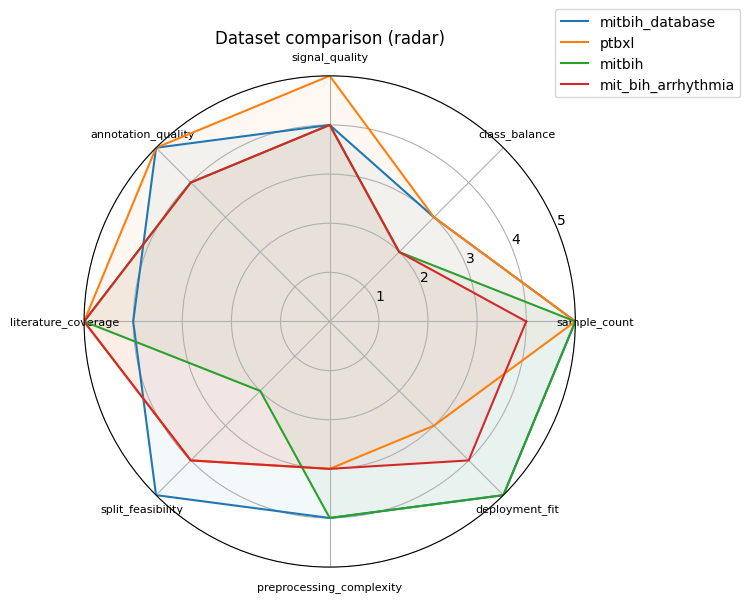

In [3]:
criteria = ['sample_count','class_balance','signal_quality','annotation_quality','literature_coverage','split_feasibility','preprocessing_complexity','deployment_fit']
angles = np.linspace(0, 2*np.pi, len(criteria), endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
for _, r in comp.iterrows():
    vals = [r[c] for c in criteria]
    vals += vals[:1]
    ax.plot(angles, vals, label=r['dataset'])
    ax.fill(angles, vals, alpha=0.05)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(criteria, fontsize=8)
ax.set_ylim(0, 5)
ax.set_yticks([1,2,3,4,5])
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
plt.title('Dataset comparison (radar)')
plt.tight_layout()
plt.show()

## Auto-select winner and export JSON

In [4]:
winner = comp.iloc[0]
selected = winner['dataset']
payload = {
  'selected_dataset': selected,
  'path': DATASET_PATHS[selected],
  'score': int(winner['total']),
  'justification': 'Highest total score across 8 criteria from EDA comparison.',
  'n_classes': 5,
  'n_samples': None,
  'task': 'classification'
}
with open(OUT / 'dataset_selection.json', 'w') as f:
    json.dump(payload, f, indent=2)
print('Selected dataset:', selected)
print('Path:', payload['path'])
print('Saved:', OUT / 'dataset_selection.json')

Selected dataset: mitbih_database
Path: /Users/ayoub/work/MS-DS_ML_Projects/IOT/mitbih_database
Saved: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/results/eda/dataset_selection.json
